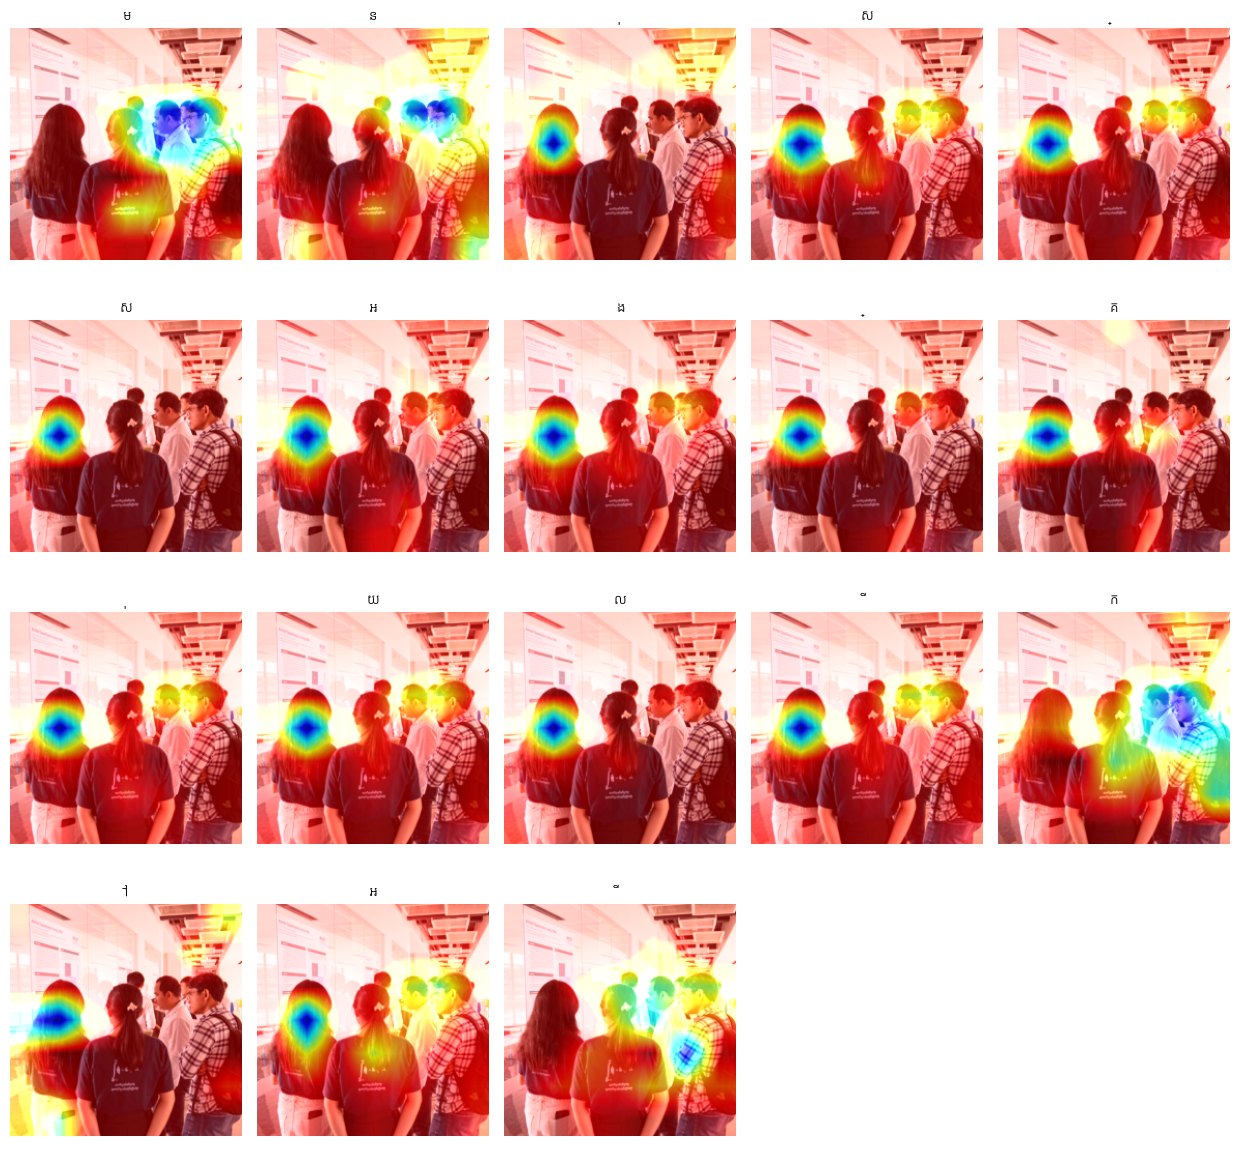

Generated Caption: មនុស្សអង្គុយលើកៅអី


In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math



# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

# GradCAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze()
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()

def overlay_heatmap(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    return np.clip(heatmap * 0.8 + img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v3.pth'))
decoder.load_state_dict(torch.load('decoder_final_v3.pth'))
encoder.eval()
decoder.eval()
gradcam = GradCAM(encoder.resnet[-1], encoder.resnet[-1][-1])

# Generate caption and visualize Grad-CAM
def generate_caption_with_gradcam(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)

    tensor_img.requires_grad = True
    encoder_out = encoder(tensor_img)
    h = decoder.init_h(encoder_out.mean(dim=1))
    c = decoder.init_c(encoder_out.mean(dim=1))

    seq = [word2idx['<START>']]
    tokens, heatmaps = [], []

    for _ in range(40):
        last_token = torch.tensor([seq[-1]]).to(device)
        output, h, c = decoder.forward_step(encoder_out, last_token, h, c)
        idx = output.argmax(1).item()
        if idx in [word2idx['<END>'], word2idx['<PAD>']]:
            break
        seq.append(idx)
        tokens.append(idx2word[str(idx)])

        # Backward pass for Grad-CAM
        encoder.zero_grad()
        decoder.zero_grad()
        output[0, idx].backward(retain_graph=True)
        cam = gradcam.generate_cam()
        heatmaps.append(overlay_heatmap(img_for_display, cam))
        
    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    # Define layout
    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    # Flatten axes if needed
    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(heatmaps[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/404843922_665977545724158_8925282881131390492_n.jpg'

# Run
caption = generate_caption_with_gradcam(image_path)
print("Generated Caption:", caption)


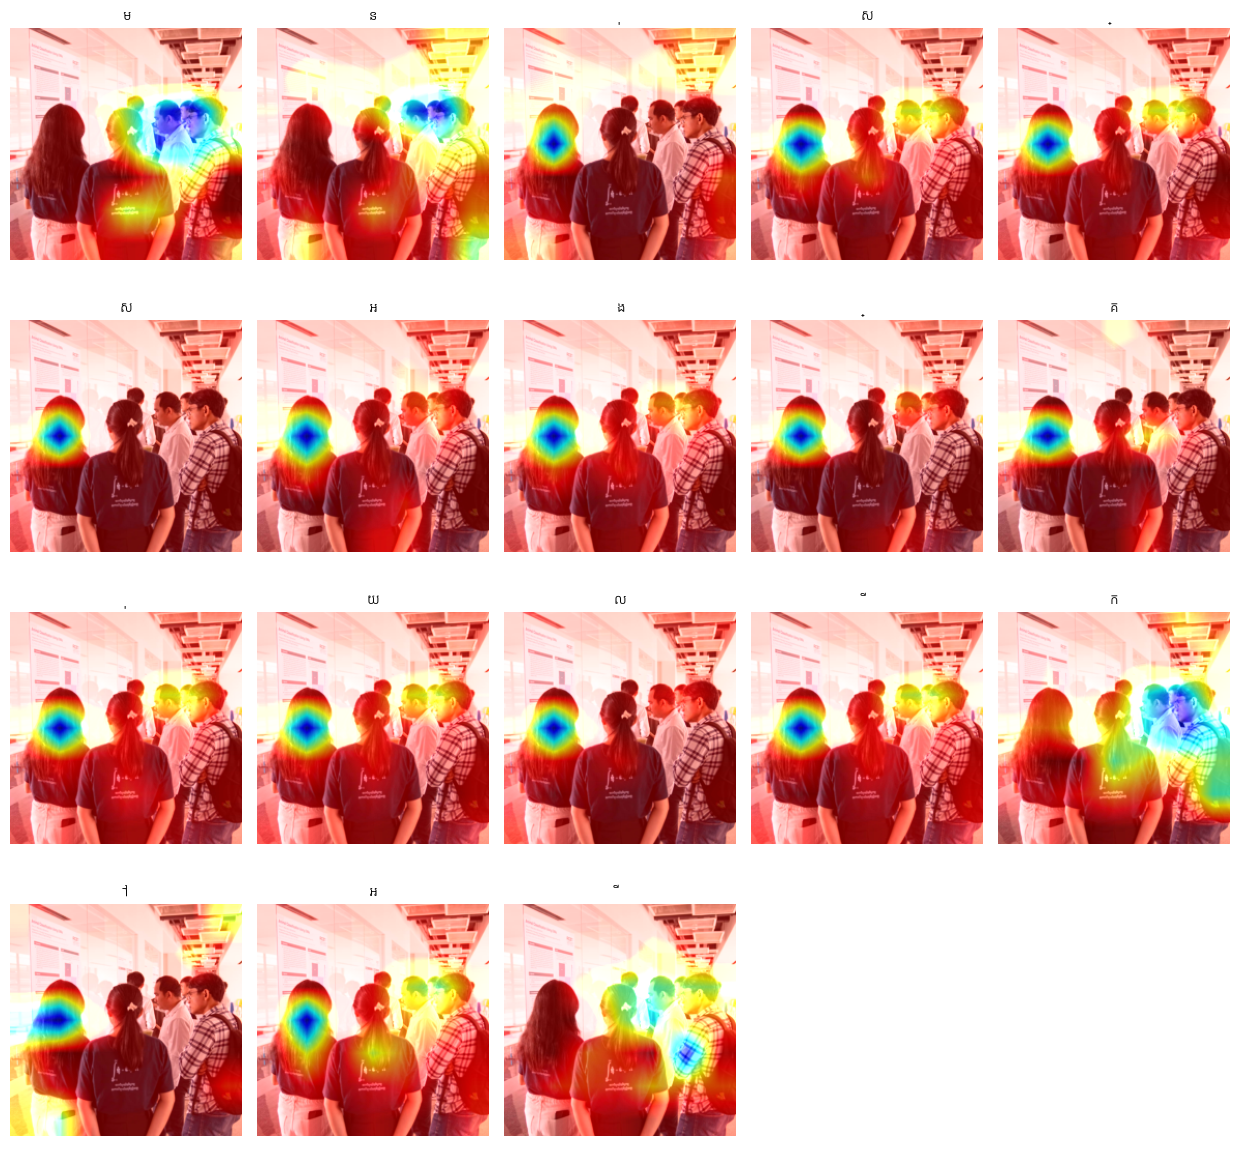

Generated Caption: មនុស្សអង្គុយលើកៅអី


In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

# GradCAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze()
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()

def overlay_heatmap(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    return np.clip(heatmap * 0.8 + img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v3.pth'))
decoder.load_state_dict(torch.load('decoder_final_v3.pth'))
encoder.eval()
decoder.eval()
gradcam = GradCAM(encoder.resnet[-1], encoder.resnet[-1][-1])

# Generate caption using beam search and visualize Grad-CAM
def generate_caption_with_gradcam(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_heatmaps = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    heatmap_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward_step(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Grad-CAM for top candidate
        decoder.zero_grad()
        encoder.zero_grad()
        outputs[prev_beam_indices[0], next_word_indices[0]].backward(retain_graph=True)
        cam = gradcam.generate_cam()
        heatmap_list[0].append(overlay_heatmap(img_for_display, cam))

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_heatmaps.extend([heatmap_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        heatmap_list = [heatmap_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_heatmaps = complete_heatmaps[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_heatmaps[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/404843922_665977545724158_8925282881131390492_n.jpg'

# Run
caption = generate_caption_with_gradcam(image_path)
print("Generated Caption:", caption)
